In [240]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [261]:
#load data
df = pd.read_stata('assignment7.dta')
df.shape
#df.head()

(30487, 28)

In [242]:
df.info()
print("\nSummary Statistics:\n", df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30487 entries, 0 to 30486
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sex           30487 non-null  category
 1   age           30487 non-null  int16   
 2   datyear       30487 non-null  float32 
 3   agelfted      30487 non-null  float32 
 4   nireland      30487 non-null  float32 
 5   yearat14      30487 non-null  float32 
 6   missing_earn  30487 non-null  float32 
 7   wght          30487 non-null  int32   
 8   ones          30487 non-null  float32 
 9   yearat14_2    30487 non-null  float32 
 10  yearat14_3    30487 non-null  float32 
 11  yearat14_4    30487 non-null  float32 
 12  age2          30487 non-null  float32 
 13  age3          30487 non-null  float32 
 14  age4          30487 non-null  float32 
 15  lhinc         15555 non-null  float32 
 16  learn         16257 non-null  float32 
 17  linc          9961 non-null   float32 
 18  goodhe

In [243]:
df["cluster_id"] = df.groupby(["yearat14", "nireland"]).ngroup()

df[["yearat14", "nireland", "cluster_id"]].head()

,yearat14,nireland,cluster_id
0,35.0,0.0,0
1,35.0,0.0,0
2,35.0,0.0,0
3,35.0,0.0,0
4,35.0,0.0,0


Question 1: Replicate Figures 4 and 6 from the paper.

In [244]:
#break into regional groups

df_gb = df[df['nireland'] == 0].copy()
df_gb[["yearat14", "nireland"]].drop_duplicates()
df_ni = df[df['nireland'] == 1].copy()
df_ni[["yearat14", "nireland"]].drop_duplicates()
df_gb.info(), df_ni.info()


<class 'pandas.core.frame.DataFrame'>
Index: 22574 entries, 0 to 30103
Data columns (total 29 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   sex           22574 non-null  category
 1   age           22574 non-null  int16   
 2   datyear       22574 non-null  float32 
 3   agelfted      22574 non-null  float32 
 4   nireland      22574 non-null  float32 
 5   yearat14      22574 non-null  float32 
 6   missing_earn  22574 non-null  float32 
 7   wght          22574 non-null  int32   
 8   ones          22574 non-null  float32 
 9   yearat14_2    22574 non-null  float32 
 10  yearat14_3    22574 non-null  float32 
 11  yearat14_4    22574 non-null  float32 
 12  age2          22574 non-null  float32 
 13  age3          22574 non-null  float32 
 14  age4          22574 non-null  float32 
 15  lhinc         15555 non-null  float32 
 16  learn         13118 non-null  float32 
 17  linc          9961 non-null   float32 
 18  goodhealth 

(None, None)

In [245]:
#restrict to 32 to 65
# Use parentheses when combining boolean masks and reference the same dataframe (df_gb)
df_gb = df_gb[(df_gb['age'] >= 32) & (df_gb['age'] <= 65) & (df_gb["learn"].notnull())].copy()

# Quick checks
print(f"GB sample after age restriction: {len(df_gb)}")
print(f"Age range after filter: {df_gb['age'].min()} - {df_gb['age'].max()}")
print(f"Missing 'learn' values: {df_gb['learn'].isna().sum()}")


GB sample after age restriction: 13115
Age range after filter: 33 - 64
Missing 'learn' values: 0


In [246]:
#weighted average for individual dots

def wmean(series, weights):
    # compute weighted mean safely (handle NaNs and zero-length)
    mask = series.notnull() & weights.notnull()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# plot average per cohort, dot per year, grouped by yearat14
# include weighted means for both agelfted and learn (log earnings)
points = (
    df_gb
    .groupby("yearat14")
    .apply(lambda g: pd.Series({
        "agelfted_mean": wmean(g["agelfted"], g["wght"]),
        "learn_mean": wmean(g["learn"], g["wght"]),
        "n": len(g)
    }))
    .reset_index()
)

points.head()


/var/folders/n9/kv5pq1015h5cxdk8s76mbdxw0000gn/T/ipykernel_65236/687482927.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,yearat14,agelfted_mean,learn_mean,n
0,35.0,14.957627,8.160411,24.0
1,36.0,14.973214,8.287352,44.0
2,37.0,14.896552,8.218967,61.0
3,38.0,15.086957,8.413887,89.0
4,39.0,14.914894,8.424010,109.0


In [247]:
#separate points before and after 1947
points_before_1947 = points[points["yearat14"] < 47]
points_after_1947 = points[points["yearat14"] >= 47]



In [248]:
#Age left model fits
coef_before_1947 = np.polyfit(points_before_1947["yearat14"], points_before_1947["agelfted_mean"], 4)
poly_before_1947 = np.poly1d(coef_before_1947)

X_before_1947 = np.linspace(points_before_1947["yearat14"].min(), points_before_1947["yearat14"].max(), 100)
y_before_1947 = poly_before_1947(X_before_1947)


coef_after_1947 = np.polyfit(points_after_1947["yearat14"], points_after_1947["agelfted_mean"], 4)
poly_after_1947 = np.poly1d(coef_after_1947)

X_after_1947 = np.linspace(points_after_1947["yearat14"].min(), points_after_1947["yearat14"].max(), 100)
y_after_1947 = poly_after_1947(X_after_1947)


#log of earnings model fit
coef_earn_before_1947 = np.polyfit(points_before_1947["yearat14"], points_before_1947["learn_mean"], 4)
poly_earn_before_1947 = np.poly1d(coef_earn_before_1947)

X_earn_before_1947 = np.linspace(points_before_1947["yearat14"].min(), points_before_1947["yearat14"].max(), 100)
y_earn_before_1947 = poly_earn_before_1947(X_earn_before_1947)


coef_earn_after_1947 = np.polyfit(points_after_1947["yearat14"], points_after_1947["learn_mean"], 4)
poly_earn_after_1947 = np.poly1d(coef_earn_after_1947)

X_earn_after_1947 = np.linspace(points_after_1947["yearat14"].min(), points_after_1947["yearat14"].max(), 100)
y_earn_after_1947 = poly_earn_after_1947(X_earn_after_1947)



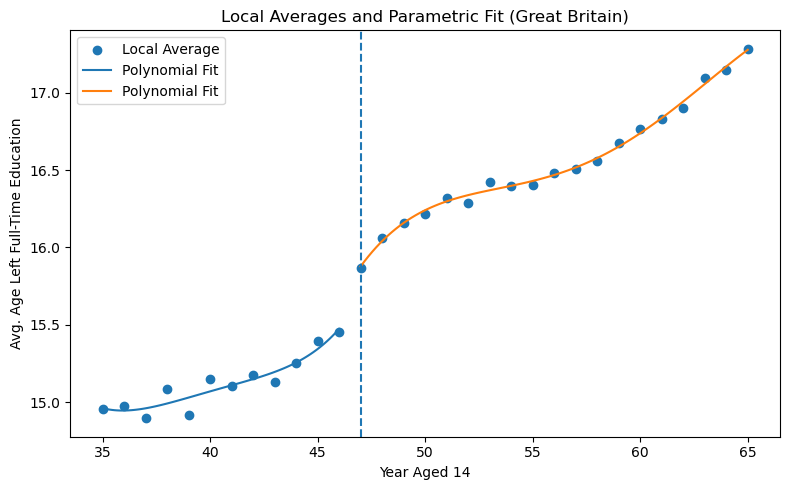

In [249]:
#now we plot

fig, ax = plt.subplots(figsize=(8, 5))

# 1) Dots: local averages
ax.scatter(points["yearat14"], points["agelfted_mean"], label="Local Average")

# 2) Line: polynomial fit
ax.plot(X_before_1947, y_before_1947, label="Polynomial Fit")
ax.plot(X_after_1947, y_after_1947, label="Polynomial Fit")

# 3) Vertical line at the reform year (1947)
ax.axvline(47, linestyle="--")

# Labels and title
ax.set_xlabel("Year Aged 14")
ax.set_ylabel("Avg. Age Left Full-Time Education")
ax.set_title("Local Averages and Parametric Fit (Great Britain)")

ax.legend()

plt.tight_layout()
plt.show()


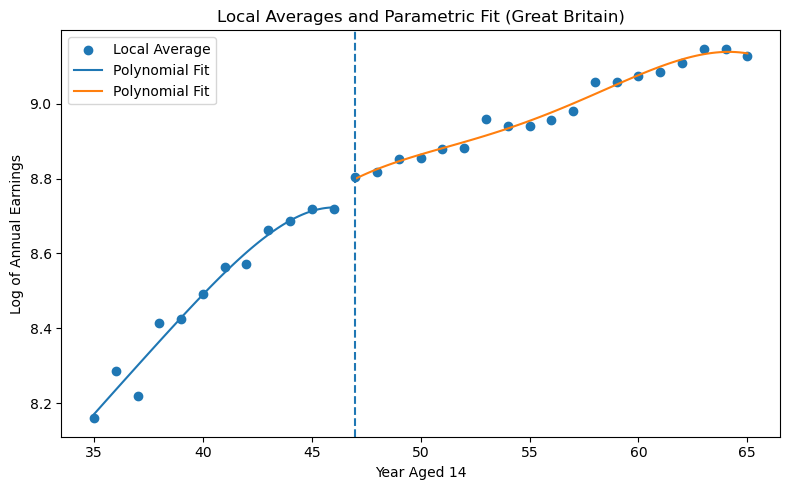

In [250]:
#now we plot

fig, ax = plt.subplots(figsize=(8, 5))

# 1) Dots: local averages
ax.scatter(points["yearat14"], points["learn_mean"], label="Local Average")

# 2) Line: polynomial fit
ax.plot(X_earn_before_1947, y_earn_before_1947, label="Polynomial Fit")
ax.plot(X_earn_after_1947, y_earn_after_1947, label="Polynomial Fit")

# 3) Vertical line at the reform year (1947)
ax.axvline(47, linestyle="--")

# Labels and title
ax.set_xlabel("Year Aged 14")
ax.set_ylabel("Log of Annual Earnings")
ax.set_title("Local Averages and Parametric Fit (Great Britain)")

ax.legend()

plt.tight_layout()
plt.show()

**EXERCISE 2**

In [420]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Funció per mitjana ponderada segura ---
def wmean(series, weights):
    mask = series.notnull() & weights.notnull()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# --- Carregar dades ---
df = pd.read_stata('assignment7.dta')

# --- Filtrar observacions ---
df = df[df["learn"].notna()]
df = df[(df["age"]>=25)&(df["age"]<=64)&(df["nireland"]==0)].copy()

# --- Crear variable Zprime i filtrar pel bandwidth ---
df["Zprime"] = df["yearat14"] - 47

# Redondejar l'edat a enter
df['age_int'] = df['age'].round().astype(int)

# Crear age dummies per cada any
age_dummies = pd.get_dummies(df['age_int'], prefix='age', drop_first=True).astype(float)

# Concatenar al df original
df = pd.concat([df, age_dummies], axis=1)

# --- Agrupament per cel·la ---
df_cells = (
    df
    .groupby(["yobirth"])
    .apply(lambda g: pd.Series({
        "agelfted_mean": wmean(g["agelfted"], g["wght"]),
        "learn_mean": wmean(g["learn"], g["wght"]),
        "indicator_mean": wmean(g["drop15"], g["wght"]),
        "Zprime_mean": wmean(g["Zprime"], g["wght"]),
        "age_mean": wmean(g["age"], g["wght"]),
        "n": g["wght"].sum(),
        **{col: wmean(g[col], g['wght']) for col in age_dummies.columns}
    }))
    .reset_index()
)

# --- Crear variables després del cluster ---
df_cells["Zprime_indicator_mean"] = df_cells["Zprime_mean"] * df_cells["indicator_mean"]

# Quartic cohort
for p in range(2,5):
    df_cells[f"yobirth{p}"] = df_cells["yobirth"] ** p

# Quartic edat
for p in range(2,5):
    df_cells[f"age{p}"] = df_cells["age_mean"] ** p

bw = 11
df_bw = df_cells[(df_cells["Zprime_mean"] >= -bw) & (df_cells["Zprime_mean"] <= bw)].copy()

# --- First Stage: DV = agelfted_mean ---
X_fs = df_bw[[
    "Zprime_mean", "indicator_mean", "Zprime_indicator_mean",
    "yobirth", "yobirth2", "yobirth3", "yobirth4"
]]
y_fs = df_bw["agelfted_mean"]

fs_model = sm.WLS(y_fs, sm.add_constant(X_fs), weights=df_bw["n"])
fs_res = fs_model.fit(cov_type="cluster", cov_kwds={"groups": df_bw["yobirth"]})
delta_hat = fs_res.params["indicator_mean"]

# --- Reduced Form: DV = learn_mean ---
X_rf = df_cells[[
    "Zprime_mean", "indicator_mean", "Zprime_indicator_mean",
    "yobirth", "yobirth2", "yobirth3", "yobirth4"
]]
y_rf = df_cells["learn_mean"]

rf_model = sm.WLS(y_rf, sm.add_constant(X_rf), weights=df_cells["n"])
rf_res = rf_model.fit(cov_type="cluster", cov_kwds={"groups": df_cells["yobirth"]})
alpha_hat = rf_res.params["indicator_mean"]


print("First stage =", round(delta_hat,3))
print("Reduced form =", round(alpha_hat,3))

print("Approx. robust SE for first stage =", round(fs_res.bse["indicator_mean"],3))
print("Approx. robust se for Reduced form =", round(rf_res.bse["indicator_mean"],3))


First stage = 0.46
Reduced form = 0.042
Approx. robust SE for first stage = 0.055
Approx. robust se for Reduced form = 0.021


/var/folders/n9/kv5pq1015h5cxdk8s76mbdxw0000gn/T/ipykernel_65236/325817255.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [ ]:
# --- First Stage: DV = agelfted_mean ---
X_fs = df_cells[[
    "Zprime_mean", "indicator_mean", "Zprime_indicator_mean",
    "yobirth", "yobirth2", "yobirth3", "yobirth4",
    "age_mean", "age2", "age3", "age4"
]]
y_fs = df_cells["agelfted_mean"]
weights = df_cells["n"]

fs_model = sm.WLS(y_fs, sm.add_constant(X_fs), weights=weights)
fs_res = fs_model.fit(cov_type="cluster", cov_kwds={"groups": df_cells["yobirth"]})
delta_hat = fs_res.params["indicator_mean"]

# --- Reduced Form: DV = learn_mean ---
X_rf = X_fs.copy()
y_rf = df_cells["learn_mean"]

rf_model = sm.WLS(y_rf, sm.add_constant(X_rf), weights=weights)
rf_res = rf_model.fit(cov_type="cluster", cov_kwds={"groups": df_cells["yobirth"]})
alpha_hat = rf_res.params["indicator_mean"]

print("First stage =", round(delta_hat,3))
print("Reduced form =", round(alpha_hat,3))

print("Approx. robust SE for first stage =", round(fs_res.bse["indicator_mean"],3))
print("Approx. robust se for Reduced form =", round(rf_res.bse["indicator_mean"],3))

First stage = 0.436
Reduced form = 0.026
Approx. robust SE for first stage = 0.061
Approx. robust se for Reduced form = 0.024


In [ ]:
age_cols = [col for col in df_cells.columns if col.startswith("age_")]

X_fs = df_cells[[
    "Zprime_mean", "indicator_mean", "Zprime_indicator_mean",
    "yobirth", "yobirth2", "yobirth3", "yobirth4"
] + age_cols]

X_fs = X_fs.astype(float)

y_fs = df_cells["agelfted_mean"]
weights = df_cells["n"]

fs_model = sm.WLS(y_fs, sm.add_constant(X_fs), weights=weights)
fs_res = fs_model.fit(cov_type="cluster", cov_kwds={"groups": df_cells["yobirth"]})
delta_hat = fs_res.params["indicator_mean"]

# --- Reduced Form ---
X_rf = X_fs.copy()
y_rf = df_cells["learn_mean"]

rf_model = sm.WLS(y_rf, sm.add_constant(X_rf), weights=weights)
rf_res = rf_model.fit(cov_type="cluster", cov_kwds={"groups": df_cells["yobirth"]})
alpha_hat = rf_res.params["indicator_mean"]

print("First stage =", round(delta_hat,3))
print("Reduced form =", round(alpha_hat,3))
print("Approx. robust SE for first stage =", round(fs_res.bse["indicator_mean"],3))
print("Approx. robust SE for reduced form =", round(rf_res.bse["indicator_mean"],3))


First stage = 0.387
Reduced form = 0.176
Approx. robust SE for first stage = nan
Approx. robust SE for reduced form = nan


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
